In [1]:
from google.colab import drive
drive.mount('/content/drive')


ValueError: mount failed

In [2]:
!pip install gdown


In [4]:
!gdown --id 12ChcgFcxxTtwZXOEFgjcDo_vEYRf0zv1


/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=12ChcgFcxxTtwZXOEFgjcDo_vEYRf0zv1
From (redirected): https://drive.google.com/uc?id=12ChcgFcxxTtwZXOEFgjcDo_vEYRf0zv1&confirm=t&uuid=426b2db3-b094-4021-8e63-5b72a6e15ddf
To: /content/suitesparse_kaggle_export.zip
100% 208M/208M [00:04<00:00, 50.3MB/s]


In [5]:
!unzip suitesparse_kaggle_export.zip


Archive:  suitesparse_kaggle_export.zip
   creating: suitesparse_mtx/
   creating: suitesparse_mtx/Bai/
   creating: suitesparse_mtx/Bai/bfwb62/
   creating: suitesparse_mtx/Bai/bfwb62/bfwb62/
  inflating: suitesparse_mtx/Bai/bfwb62/bfwb62/bfwb62.mtx  
   creating: suitesparse_mtx/Bai/mhdb416/
   creating: suitesparse_mtx/Bai/mhdb416/mhdb416/
  inflating: suitesparse_mtx/Bai/mhdb416/mhdb416/mhdb416.mtx  
   creating: suitesparse_mtx/Bai/olm2000/
   creating: suitesparse_mtx/Bai/olm2000/olm2000/
  inflating: suitesparse_mtx/Bai/olm2000/olm2000/olm2000.mtx  
   creating: suitesparse_mtx/Bai/rw136/
   creating: suitesparse_mtx/Bai/rw136/rw136/
  inflating: suitesparse_mtx/Bai/rw136/rw136/rw136.mtx  
   creating: suitesparse_mtx/Bai/dw256A/
   creating: suitesparse_mtx/Bai/dw256A/dw256A/
  inflating: suitesparse_mtx/Bai/dw256A/dw256A/dw256A.mtx  
   creating: suitesparse_mtx/Bai/cdde3/
   creating: suitesparse_mtx/Bai/cdde3/cdde3/
  inflating: suitesparse_mtx/Bai/cdde3/cdde3/cdde3.mtx  
  

In [6]:
!pip install ssgetpy -q


In [7]:
import json
import ssgetpy
from pathlib import Path

data_dir = Path("suitesparse_mtx")

# Load the saved metadata
with open("suitesparse_selected.json") as f:
    meta = json.load(f)

print("Matrices listed in JSON:", len(meta))

# Rebuild selected list exactly as in kaggle
selected = []
for item in meta:
    g = item["group"]
    n = item["name"]
    try:
        # Fetch the exact matrix entry from SuiteSparse DB metadata
        m = ssgetpy.search(group=g, name=n, limit=1)[0]
        selected.append(m)
    except:
        print("Could not find:", g, n)

print("Reconstructed selected list:", len(selected))


Matrices listed in JSON: 500
Reconstructed selected list: 500


In [8]:
from pathlib import Path
import scipy.io
import scipy.sparse as sp
import numpy as np

data_dir = Path("suitesparse_mtx")

def load_matrix_metadata(m):
    """
    Given an ssgetpy Matrix object m (with .group and .name),
    recursively find a .mtx file under suitesparse_mtx/group/name/,
    load it as SciPy CSR (float64), and return it.
    """
    base_dir = data_dir / m.group / m.name

    if not base_dir.exists():
        print(f"[WARN] Directory not found for {m.group}/{m.name}: {base_dir}")
        return None

    # Recursively search for any .mtx file
    mtx_file = None
    for f in base_dir.rglob("*.mtx"):
        mtx_file = f
        break  # first match

    if mtx_file is None:
        print(f"[WARN] No .mtx file found under {base_dir}")
        return None

    print(f"Loading {m.group}/{m.name} from {mtx_file.relative_to(data_dir)}")
    A = scipy.io.mmread(str(mtx_file))
    A = A.tocsr().astype(np.float64)   # ensure CSR float64

    print(f"  shape: {A.shape}, nnz: {A.nnz}, dtype: {A.dtype}")
    return A

# 🔍 Test on first 3 matrices
print("Testing loader on a few matrices...")
for m in selected[:3]:
    A = load_matrix_metadata(m)
    print("-" * 60)


Testing loader on a few matrices...
Loading HB/1138_bus from HB/1138_bus/1138_bus/1138_bus.mtx
  shape: (1138, 1138), nnz: 4054, dtype: float64
------------------------------------------------------------
Loading HB/494_bus from HB/494_bus/494_bus/494_bus.mtx
  shape: (494, 494), nnz: 1666, dtype: float64
------------------------------------------------------------
Loading HB/662_bus from HB/662_bus/662_bus/662_bus.mtx
  shape: (662, 662), nnz: 2474, dtype: float64
------------------------------------------------------------


In [9]:
# Install CuPy for CUDA 12 (works on current Colab GPUs)
!pip install -q cupy-cuda12x

import cupy as cp
import time
import scipy.sparse as sp
import numpy as np

def scipy_to_cupy_csr(A, dtype=cp.float64):
    """
    Convert a SciPy CSR matrix A to a CuPy CSR matrix with given dtype.
    """
    A = A.tocsr()
    data   = cp.asarray(A.data,   dtype=dtype)
    indices = cp.asarray(A.indices, dtype=cp.int32)
    indptr  = cp.asarray(A.indptr,  dtype=cp.int32)
    return cp.sparse.csr_matrix((data, indices, indptr), shape=A.shape)

def gpu_reference_spmv(A, n_runs=5):
    """
    Reference SpMV on GPU in float64 precision.

    Returns:
        A64_gpu : CuPy CSR (float64)
        x_ref   : CuPy dense vector (float64)
        y_ref   : CuPy dense vector (float64)
        avg_t   : average execution time over n_runs (seconds)
    """
    # 1) Move A to GPU in float64
    A64_gpu = scipy_to_cupy_csr(A, dtype=cp.float64)

    n = A.shape[1]
    x_ref = cp.random.randn(n, dtype=cp.float64)

    # 2) Warm-up (to avoid including one-time overhead)
    _ = A64_gpu @ x_ref
    cp.cuda.Stream.null.synchronize()

    # 3) Timed runs
    t0 = time.time()
    for _ in range(n_runs):
        y_ref = A64_gpu @ x_ref
    cp.cuda.Stream.null.synchronize()

    avg_t = (time.time() - t0) / n_runs
    return A64_gpu, x_ref, y_ref, avg_t

# 🔍 Quick sanity test on the first matrix
m_test = selected[0]
A_test = load_matrix_metadata(m_test)

A64_gpu, x_ref, y_ref, t_ref = gpu_reference_spmv(A_test)
print(f"Test matrix: {m_test.group}/{m_test.name}")
print("  shape:", A_test.shape, "nnz:", A_test.nnz)
print(f"  Reference GPU SpMV avg time: {t_ref:.6e} s")
print("  ||y_ref|| (L2 norm):", float(cp.linalg.norm(y_ref)))


Loading HB/1138_bus from HB/1138_bus/1138_bus/1138_bus.mtx
  shape: (1138, 1138), nnz: 4054, dtype: float64
Test matrix: HB/1138_bus
  shape: (1138, 1138) nnz: 4054
  Reference GPU SpMV avg time: 1.161575e-04 s
  ||y_ref|| (L2 norm): 132701.01384306516


In [10]:
import scipy.sparse as sp

def build_entrywise_matrices(A, thresh=1.0):
    """
    Split entries of A by magnitude:

      - A_hi: |a_ij| >= thresh
      - A_lo: |a_ij| <  thresh

    Returns two SciPy CSR matrices.
    """
    A = A.tocoo()
    data = A.data
    rows = A.row
    cols = A.col

    mask_hi = np.abs(data) >= thresh
    mask_lo = ~mask_hi

    A_hi = sp.coo_matrix((data[mask_hi], (rows[mask_hi], cols[mask_hi])),
                         shape=A.shape).tocsr()
    A_lo = sp.coo_matrix((data[mask_lo], (rows[mask_lo], cols[mask_lo])),
                         shape=A.shape).tocsr()
    return A_hi, A_lo

def eval_entrywise_spmv(A, x_ref, y_ref, thresh=1.0, n_runs=5):
    """
    Entry-wise mixed precision SpMV:

      - A_hi stored and multiplied in float64
      - A_lo stored and multiplied in float32
      - Both results accumulated in float64

    A: SciPy sparse matrix (CSR/COO/etc)
    x_ref, y_ref: CuPy vectors from gpu_reference_spmv
    """
    # 1) Split into high/low magnitude matrices on CPU
    A_hi, A_lo = build_entrywise_matrices(A, thresh=thresh)

    # 2) Move to GPU with desired precisions
    A_hi_gpu = scipy_to_cupy_csr(A_hi, dtype=cp.float64)
    A_lo_gpu = scipy_to_cupy_csr(A_lo, dtype=cp.float32)

    # 3) Prepare x in both precisions
    x64 = x_ref
    x32 = x_ref.astype(cp.float32)

    # 4) Warm-up
    _ = A_hi_gpu @ x64
    _ = A_lo_gpu @ x32
    cp.cuda.Stream.null.synchronize()

    # 5) Timed runs
    t0 = time.time()
    for _ in range(n_runs):
        y_hi = A_hi_gpu @ x64
        y_lo = A_lo_gpu @ x32
        y    = y_hi + y_lo.astype(cp.float64)
    cp.cuda.Stream.null.synchronize()
    avg_t = (time.time() - t0) / n_runs

    # 6) Relative error vs reference
    rel_err = cp.linalg.norm(y - y_ref) / cp.linalg.norm(y_ref)
    return avg_t, float(rel_err)

# 🔍 Quick test on the same test matrix as before
m_test = selected[0]
A_test = load_matrix_metadata(m_test)

A64_gpu, x_ref, y_ref, t_ref = gpu_reference_spmv(A_test)
print(f"Reference time (float64): {t_ref:.6e} s")

t_entry, e_entry = eval_entrywise_spmv(A_test, x_ref, y_ref, thresh=1.0)
print(f"Entry-wise time: {t_entry:.6e} s,  rel_err = {e_entry:.3e}")


Loading HB/1138_bus from HB/1138_bus/1138_bus/1138_bus.mtx
  shape: (1138, 1138), nnz: 4054, dtype: float64
Reference time (float64): 9.574890e-05 s
Entry-wise time: 5.975127e-02 s,  rel_err = 1.534e-12


In [11]:
def build_rowwise_matrices(A, frac_high=0.3):
    """
    Split rows by importance using max |a_ij| per row.

    Top frac_high fraction of rows go to high precision (A_hi),
    remaining rows go to low precision (A_lo).
    """
    A = A.tocsr()
    n_rows = A.shape[0]
    row_max = np.zeros(n_rows, dtype=np.float64)

    data = A.data
    indptr = A.indptr

    # Compute max |a_ij| per row
    for i in range(n_rows):
        s, e = indptr[i], indptr[i+1]
        if s == e:
            row_max[i] = 0.0
        else:
            row_max[i] = np.max(np.abs(data[s:e]))

    # Determine threshold to pick top frac_high rows
    q = np.quantile(row_max, 1.0 - frac_high)
    hi_mask = row_max >= q
    lo_mask = ~hi_mask

    A_hi = A[hi_mask, :]
    A_lo = A[lo_mask, :]

    return A_hi, A_lo, hi_mask, lo_mask

def eval_rowwise_spmv(A, x_ref, y_ref, frac_high=0.3, n_runs=5):
    """
    Row-wise mixed precision SpMV:

      - High-importance rows in float64 (A_hi)
      - Remaining rows in float32 (A_lo)

    A: SciPy sparse matrix
    x_ref, y_ref: CuPy vectors from gpu_reference_spmv
    """
    # 1) Build high/low row blocks
    A_hi, A_lo, hi_mask, lo_mask = build_rowwise_matrices(A, frac_high=frac_high)

    # 2) Move row blocks to GPU
    A_hi_gpu = scipy_to_cupy_csr(A_hi, dtype=cp.float64)
    A_lo_gpu = scipy_to_cupy_csr(A_lo, dtype=cp.float32)

    x64 = x_ref
    x32 = x_ref.astype(cp.float32)

    # 3) Warm-up
    _ = A_hi_gpu @ x64
    _ = A_lo_gpu @ x32
    cp.cuda.Stream.null.synchronize()

    # 4) Timed runs
    t0 = time.time()
    for _ in range(n_runs):
        y_hi = A_hi_gpu @ x64   # high-precision rows
        y_lo = A_lo_gpu @ x32   # low-precision rows
    cp.cuda.Stream.null.synchronize()
    avg_t = (time.time() - t0) / n_runs

    # 5) Reconstruct full y in original row order
    y_full = cp.zeros_like(y_ref)
    hi_idx = np.where(hi_mask)[0]
    lo_idx = np.where(lo_mask)[0]

    y_full[hi_idx] = y_hi
    y_full[lo_idx] = y_lo.astype(cp.float64)

    # 6) Relative error vs reference
    rel_err = cp.linalg.norm(y_full - y_ref) / cp.linalg.norm(y_ref)
    return avg_t, float(rel_err)

# 🔍 Quick test on the same test matrix
m_test = selected[0]
A_test = load_matrix_metadata(m_test)

A64_gpu, x_ref, y_ref, t_ref = gpu_reference_spmv(A_test)
print(f"Reference time (float64): {t_ref:.6e} s")

t_row, e_row = eval_rowwise_spmv(A_test, x_ref, y_ref, frac_high=0.3)
print(f"Row-wise time: {t_row:.6e} s,  rel_err = {e_row:.3e}")


Loading HB/1138_bus from HB/1138_bus/1138_bus/1138_bus.mtx
  shape: (1138, 1138), nnz: 4054, dtype: float64
Reference time (float64): 1.270294e-04 s
Row-wise time: 1.409054e-04 s,  rel_err = 1.053e-09


In [12]:
def build_adaptive_matrices(A, quantile=0.7):
    """
    2-bucket adaptive split by |a_ij|:
      - A_hi: entries >= quantile(|a|)
      - A_lo: entries <  quantile(|a|)
    """
    A = A.tocoo()
    data = A.data
    rows = A.row
    cols = A.col

    abs_data = np.abs(data)
    if abs_data.size == 0:
        Z = sp.csr_matrix(A.shape, dtype=np.float64)
        return Z, Z

    thresh = np.quantile(abs_data, quantile)

    mask_hi = abs_data >= thresh
    mask_lo = abs_data <  thresh

    A_hi = sp.coo_matrix((data[mask_hi], (rows[mask_hi], cols[mask_hi])),
                         shape=A.shape).tocsr()
    A_lo = sp.coo_matrix((data[mask_lo], (rows[mask_lo], cols[mask_lo])),
                         shape=A.shape).tocsr()

    return A_hi, A_lo

def eval_adaptive_spmv(A, x_ref, y_ref, quantile=0.7, n_runs=5):
    """
    Adaptive mixed precision SpMV:

      - High bucket (>= quantile) -> float64
      - Low bucket  (< quantile)  -> float32
    """
    # 1) Build high/low matrices
    A_hi, A_lo = build_adaptive_matrices(A, quantile=quantile)

    # 2) Move to GPU with desired precision
    A_hi_gpu = scipy_to_cupy_csr(A_hi, dtype=cp.float64)
    A_lo_gpu = scipy_to_cupy_csr(A_lo, dtype=cp.float32)

    x64 = x_ref
    x32 = x_ref.astype(cp.float32)

    # 3) Warm-up
    _ = A_hi_gpu @ x64
    _ = A_lo_gpu @ x32
    cp.cuda.Stream.null.synchronize()

    # 4) Timed runs
    t0 = time.time()
    for _ in range(n_runs):
        y_hi = A_hi_gpu @ x64
        y_lo = A_lo_gpu @ x32
        y    = y_hi + y_lo.astype(cp.float64)
    cp.cuda.Stream.null.synchronize()

    avg_t  = (time.time() - t0) / n_runs
    rel_err = cp.linalg.norm(y - y_ref) / cp.linalg.norm(y_ref)
    return avg_t, float(rel_err)

# 🔍 Quick test on the same test matrix
m_test = selected[0]
A_test = load_matrix_metadata(m_test)

A64_gpu, x_ref, y_ref, t_ref = gpu_reference_spmv(A_test)
print(f"Reference time (float64): {t_ref:.6e} s")

t_adapt, e_adapt = eval_adaptive_spmv(A_test, x_ref, y_ref, quantile=0.7)
print(f"Adaptive time: {t_adapt:.6e} s,  rel_err = {e_adapt:.3e}")


Loading HB/1138_bus from HB/1138_bus/1138_bus/1138_bus.mtx
  shape: (1138, 1138), nnz: 4054, dtype: float64
Reference time (float64): 3.490448e-04 s
Adaptive time: 1.010466e-03 s,  rel_err = 5.956e-10


In [13]:
import json
from tqdm.auto import tqdm

err_tol = 1e-3   # maximum allowed relative error
labels = {}      # "group/name" -> 0/1/2
stats  = {}      # detailed timings + errors

for m in tqdm(selected, desc="Labeling matrices"):
    name = f"{m.group}/{m.name}"

    try:
        # 1) Load matrix
        A = load_matrix_metadata(m)
        if A is None:
            print(f"[SKIP] Could not load {name}")
            continue

        # 2) Reference SpMV (float64 on GPU)
        A64_gpu, x_ref, y_ref, t_ref = gpu_reference_spmv(A)

        # 3) Evaluate three strategies
        t_ent, e_ent = eval_entrywise_spmv(A, x_ref, y_ref, thresh=1.0)
        t_row, e_row = eval_rowwise_spmv(A, x_ref, y_ref, frac_high=0.3)
        t_adp, e_adp = eval_adaptive_spmv(A, x_ref, y_ref, quantile=0.7)

        methods = [
            {"name": "entrywise", "time": t_ent, "err": e_ent, "label": 0},
            {"name": "rowwise",   "time": t_row, "err": e_row, "label": 1},
            {"name": "adaptive",  "time": t_adp, "err": e_adp, "label": 2},
        ]

        # save raw stats
        stats[name] = methods

        # 4) Filter by error tolerance
        feasible = [mt for mt in methods if mt["err"] <= err_tol]

        if feasible:
            best = min(feasible, key=lambda d: d["time"])
        else:
            best = min(methods, key=lambda d: d["time"])

        # 5) Store best label
        labels[name] = best["label"]

    except Exception as e:
        print(f"[ERROR] {name}: {e}")
        continue

# 6) Save results
with open("labels.json", "w") as f:
    json.dump(labels, f, indent=2)

with open("stats.json", "w") as f:
    json.dump(stats, f, indent=2)

print("Done. Labeled matrices:", len(labels))
print("Label distribution:", {
    lbl: list(labels.values()).count(lbl) for lbl in sorted(set(labels.values()))
})

Labeling matrices:   0%|          | 0/500 [00:00<?, ?it/s]

Loading HB/1138_bus from HB/1138_bus/1138_bus/1138_bus.mtx
  shape: (1138, 1138), nnz: 4054, dtype: float64
Loading HB/494_bus from HB/494_bus/494_bus/494_bus.mtx
  shape: (494, 494), nnz: 1666, dtype: float64
Loading HB/662_bus from HB/662_bus/662_bus/662_bus.mtx
  shape: (662, 662), nnz: 2474, dtype: float64
Loading HB/685_bus from HB/685_bus/685_bus/685_bus.mtx
  shape: (685, 685), nnz: 3249, dtype: float64
Loading HB/arc130 from HB/arc130/arc130/arc130.mtx
  shape: (130, 130), nnz: 1282, dtype: float64
Loading HB/bcsstk01 from HB/bcsstk01/bcsstk01/bcsstk01.mtx
  shape: (48, 48), nnz: 400, dtype: float64
Loading HB/bcsstk02 from HB/bcsstk02/bcsstk02/bcsstk02.mtx
  shape: (66, 66), nnz: 4356, dtype: float64
Loading HB/bcsstk03 from HB/bcsstk03/bcsstk03/bcsstk03.mtx
  shape: (112, 112), nnz: 640, dtype: float64
Loading HB/bcsstk04 from HB/bcsstk04/bcsstk04/bcsstk04.mtx
  shape: (132, 132), nnz: 3648, dtype: float64
Loading HB/bcsstk05 from HB/bcsstk05/bcsstk05/bcsstk05.mtx
  shape: (1

In [14]:
import numpy as np
import json
from tqdm import tqdm

def sparse_to_image(A, H=128, W=128):
    """
    Convert a sparse matrix A into a fixed-size HxW image
    using coordinate binning + normalized magnitude.
    """
    A = A.tocoo()
    n_rows, n_cols = A.shape

    if A.nnz == 0:
        return np.zeros((H, W), dtype=np.float32)

    rows = A.row.astype(np.float64)
    cols = A.col.astype(np.float64)
    vals = A.data.astype(np.float64)

    # 1) Scale coordinates to [0, H-1] and [0, W-1]
    r_scaled = np.floor(rows * (H - 1) / max(n_rows - 1, 1)).astype(int)
    c_scaled = np.floor(cols * (W - 1) / max(n_cols - 1, 1)).astype(int)

    # 2) Normalize |vals| to [0,1]
    v_abs = np.abs(vals)
    v_min, v_max = v_abs.min(), v_abs.max()
    if v_max - v_min < 1e-12:
        v_norm = np.zeros_like(v_abs)
    else:
        v_norm = (v_abs - v_min) / (v_max - v_min)

    # 3) Accumulate into image
    img = np.zeros((H, W), dtype=np.float32)
    np.add.at(img, (r_scaled, c_scaled), v_norm)

    # 4) Normalize whole image to [0,1]
    max_val = img.max()
    if max_val > 0:
        img /= max_val

    return img

# --- Load labels ---
with open("labels.json", "r") as f:
    labels = json.load(f)

H = W = 128
X_list = []
y_list = []
name_list = []

print("Total labeled matrices:", len(labels))

for m in tqdm(selected, desc="Building images"):
    name = f"{m.group}/{m.name}"
    if name not in labels:
        continue

    A = load_matrix_metadata(m)
    if A is None:
        continue

    img = sparse_to_image(A, H=H, W=W)
    X_list.append(img)
    y_list.append(labels[name])
    name_list.append(name)

X = np.stack(X_list, axis=0).astype(np.float32)   # (N, 128, 128)
y = np.array(y_list, dtype=np.int64)              # (N,)

np.save("X_images.npy", X)
np.save("y_labels.npy", y)

print("Final dataset shape:")
print("  X:", X.shape)
print("  y:", y.shape)
print("Label counts:", {int(k): int((y == k).sum()) for k in np.unique(y)})


Total labeled matrices: 385


Building images:   4%|▍         | 20/500 [00:00<00:02, 188.04it/s]

Loading HB/1138_bus from HB/1138_bus/1138_bus/1138_bus.mtx
  shape: (1138, 1138), nnz: 4054, dtype: float64
Loading HB/494_bus from HB/494_bus/494_bus/494_bus.mtx
  shape: (494, 494), nnz: 1666, dtype: float64
Loading HB/662_bus from HB/662_bus/662_bus/662_bus.mtx
  shape: (662, 662), nnz: 2474, dtype: float64
Loading HB/685_bus from HB/685_bus/685_bus/685_bus.mtx
  shape: (685, 685), nnz: 3249, dtype: float64
Loading HB/arc130 from HB/arc130/arc130/arc130.mtx
  shape: (130, 130), nnz: 1282, dtype: float64
Loading HB/bcsstk01 from HB/bcsstk01/bcsstk01/bcsstk01.mtx
  shape: (48, 48), nnz: 400, dtype: float64
Loading HB/bcsstk02 from HB/bcsstk02/bcsstk02/bcsstk02.mtx
  shape: (66, 66), nnz: 4356, dtype: float64
Loading HB/bcsstk03 from HB/bcsstk03/bcsstk03/bcsstk03.mtx
  shape: (112, 112), nnz: 640, dtype: float64
Loading HB/bcsstk04 from HB/bcsstk04/bcsstk04/bcsstk04.mtx
  shape: (132, 132), nnz: 3648, dtype: float64
Loading HB/bcsstk05 from HB/bcsstk05/bcsstk05/bcsstk05.mtx
  shape: (1

Building images:  20%|██        | 100/500 [00:00<00:02, 187.16it/s]

Loading HB/bcsstm07 from HB/bcsstm07/bcsstm07/bcsstm07.mtx
  shape: (420, 420), nnz: 7252, dtype: float64
Loading HB/bcsstm08 from HB/bcsstm08/bcsstm08/bcsstm08.mtx
  shape: (1074, 1074), nnz: 1074, dtype: float64
Loading HB/bcsstm09 from HB/bcsstm09/bcsstm09/bcsstm09.mtx
  shape: (1083, 1083), nnz: 1083, dtype: float64
Loading HB/bcsstm10 from HB/bcsstm10/bcsstm10/bcsstm10.mtx
  shape: (1086, 1086), nnz: 22092, dtype: float64
Loading HB/bcsstm11 from HB/bcsstm11/bcsstm11/bcsstm11.mtx
  shape: (1473, 1473), nnz: 1473, dtype: float64
Loading HB/bcsstm12 from HB/bcsstm12/bcsstm12/bcsstm12.mtx
  shape: (1473, 1473), nnz: 19659, dtype: float64
Loading HB/bcsstm13 from HB/bcsstm13/bcsstm13/bcsstm13.mtx
  shape: (2003, 2003), nnz: 21943, dtype: float64
Loading HB/bcsstm19 from HB/bcsstm19/bcsstm19/bcsstm19.mtx
  shape: (817, 817), nnz: 817, dtype: float64
Loading HB/bcsstm20 from HB/bcsstm20/bcsstm20/bcsstm20.mtx
  shape: (485, 485), nnz: 485, dtype: float64
Loading HB/bcsstm21 from HB/bcsst

...

Loading Hollinger/g7jac140sc from Hollinger/g7jac140sc/g7jac140sc/g7jac140sc.mtx
  shape: (41490, 41490), nnz: 565956, dtype: float64
Loading Hollinger/g7jac160 from Hollinger/g7jac160/g7jac160/g7jac160.mtx
  shape: (47430, 47430), nnz: 656616, dtype: float64
Loading Hollinger/g7jac160sc from Hollinger/g7jac160sc/g7jac160sc/g7jac160sc.mtx
  shape: (47430, 47430), nnz: 656616, dtype: float64


Building images:  82%|████████▏ | 409/500 [00:07<00:02, 33.41it/s]

Loading Hollinger/jan99jac040 from Hollinger/jan99jac040/jan99jac040/jan99jac040.mtx
  shape: (13694, 13694), nnz: 82842, dtype: float64
Loading Hollinger/jan99jac060sc from Hollinger/jan99jac060sc/jan99jac060sc/jan99jac060sc.mtx
  shape: (20614, 20614), nnz: 127182, dtype: float64
Loading Hollinger/jan99jac120sc from Hollinger/jan99jac120sc/jan99jac120sc/jan99jac120sc.mtx
  shape: (41374, 41374), nnz: 260202, dtype: float64
Loading Hollinger/mark3jac020 from Hollinger/mark3jac020/mark3jac020/mark3jac020.mtx
  shape: (9129, 9129), nnz: 56175, dtype: float64
Loading Hollinger/mark3jac020sc from Hollinger/mark3jac020sc/mark3jac020sc/mark3jac020sc.mtx
  shape: (9129, 9129), nnz: 56175, dtype: float64
Loading Hollinger/mark3jac040 from Hollinger/mark3jac040/mark3jac040/mark3jac040.mtx
  shape: (18289, 18289), nnz: 113435, dtype: float64
Loading Hollinger/mark3jac040sc from Hollinger/mark3jac040sc/mark3jac040sc/mark3jac040sc.mtx
  shape: (18289, 18289), nnz: 113435, dtype: float64
Loading H

Building images: 100%|██████████| 500/500 [00:07<00:00, 67.02it/s]

Loading Hollinger/mark3jac100 from Hollinger/mark3jac100/mark3jac100/mark3jac100.mtx
  shape: (45769, 45769), nnz: 285215, dtype: float64
Loading Hollinger/mark3jac100sc from Hollinger/mark3jac100sc/mark3jac100sc/mark3jac100sc.mtx
  shape: (45769, 45769), nnz: 285215, dtype: float64
Loading LPnetlib/lp_adlittle from LPnetlib/lp_adlittle/lp_adlittle/lp_adlittle.mtx
  shape: (56, 138), nnz: 424, dtype: float64
Loading LPnetlib/lp_agg from LPnetlib/lp_agg/lp_agg/lp_agg.mtx
  shape: (488, 615), nnz: 2862, dtype: float64
Loading LPnetlib/lp_bnl1 from LPnetlib/lp_bnl1/lp_bnl1/lp_bnl1.mtx
  shape: (643, 1586), nnz: 5532, dtype: float64
Loading LPnetlib/lp_cre_a from LPnetlib/lp_cre_a/lp_cre_a/lp_cre_a.mtx
  shape: (3516, 7248), nnz: 18168, dtype: float64
Loading LPnetlib/lp_etamacro from LPnetlib/lp_etamacro/lp_etamacro/lp_etamacro.mtx
  shape: (400, 816), nnz: 2537, dtype: float64
Loading LPnetlib/lp_finnis from LPnetlib/lp_finnis/lp_finnis/lp_finnis.mtx
  shape: (497, 1064), nnz: 2760, dtyp

In [15]:
import numpy as np

# Load original (unbalanced) dataset
X = np.load("X_images.npy")      # shape: (N, 128, 128)
y = np.load("y_labels.npy")      # shape: (N,)

print("Original X shape:", X.shape)
print("Original y shape:", y.shape)

unique, counts = np.unique(y, return_counts=True)
print("Original class counts:")
for c, cnt in zip(unique, counts):
    print(f"  class {c}: {cnt}")


Original X shape: (385, 128, 128)
Original y shape: (385,)
Original class counts:
  class 0: 14
  class 1: 362
  class 2: 9


In [17]:
import numpy as np

def augment_sparse_image(img, noise_std=0.03, drop_prob=0.01):
    """
    Structure-aware augmentation for sparse matrix images.
    - img: (H, W) in [0,1]
    - Add small noise only on non-zero pixels
    - Randomly drop a tiny fraction of non-zero pixels
    """
    aug = img.copy()

    # Non-zero structure mask
    mask = aug > 0

    if mask.sum() == 0:
        # If matrix is completely empty, do nothing
        return aug

    # 1) Small Gaussian noise on non-zero pixels
    noise = np.random.normal(loc=0.0, scale=noise_std, size=aug.shape).astype(np.float32)
    aug[mask] = aug[mask] + noise[mask]

    # 2) Randomly drop a small fraction of non-zero pixels
    drop_mask = (np.random.rand(*aug.shape) < drop_prob) & mask
    aug[drop_mask] = 0.0

    # 3) Clip back to [0,1]
    aug = np.clip(aug, 0.0, 1.0)

    return aug


In [18]:
N_AUG = 5  # number of augmentations per minority sample

X_list = []
y_list = []

# 1) Add all original samples
for i in range(len(X)):
    X_list.append(X[i])
    y_list.append(int(y[i]))

# 2) Augment minority classes (0 and 2)
minority_classes = [0, 2]

for cls in minority_classes:
    idxs = np.where(y == cls)[0]
    print(f"Class {cls}: original count = {len(idxs)}")

    for idx in idxs:
        img = X[idx]
        for _ in range(N_AUG):
            aug_img = augment_sparse_image(img)
            X_list.append(aug_img)
            y_list.append(cls)

X_aug = np.stack(X_list, axis=0).astype(np.float32)
y_aug = np.array(y_list, dtype=np.int64)

print("Augmented X shape:", X_aug.shape)
print("Augmented y shape:", y_aug.shape)

unique, counts = np.unique(y_aug, return_counts=True)
print("Augmented class counts:")
for c, cnt in zip(unique, counts):
    print(f"  class {c}: {cnt}")


Class 0: original count = 14
Class 2: original count = 9
Augmented X shape: (500, 128, 128)
Augmented y shape: (500,)
Augmented class counts:
  class 0: 84
  class 1: 362
  class 2: 54


In [19]:
import torch
from torch.utils.data import TensorDataset, DataLoader, random_split

print("Final augmented dataset shape:", X_aug.shape, y_aug.shape)

# Convert to tensors; add channel dim (N, 1, 128, 128)
X_t = torch.from_numpy(X_aug).unsqueeze(1).float()   # (N, 1, 128, 128)
y_t = torch.from_numpy(y_aug).long()                 # (N,)

dataset = TensorDataset(X_t, y_t)

# 80/20 train/val split
N = len(dataset)
n_train = int(0.8 * N)
n_val = N - n_train

train_ds, val_ds = random_split(dataset, [n_train, n_val])

print("Total samples:", N)
print("Train size:", len(train_ds), "Val size:", len(val_ds))

batch_size = 32

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=batch_size, shuffle=False)


Final augmented dataset shape: (500, 128, 128) (500,)
Total samples: 500
Train size: 400 Val size: 100


In [24]:
import torch.nn as nn
import torch.nn.functional as F

class PrecisionCNN(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),   # (16, 64, 64)

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),   # (32, 32, 32)

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),   # (64, 16, 16)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 16 * 16, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = PrecisionCNN(num_classes=3).to(device)

print("Using device:", device)


Using device: cuda


In [25]:
!nvidia --smi


/bin/bash: line 1: nvidia: command not found


In [26]:
import numpy as np
import torch

# y_aug is still in NumPy form from earlier
classes = np.array([0, 1, 2], dtype=np.int64)
class_counts = np.array([(y_aug == c).sum() for c in classes], dtype=np.float32)

print("Class counts (augmented):", dict(zip(classes, class_counts)))

# Inverse frequency weights
class_weights = 1.0 / class_counts

# Optional: normalize so that average weight ≈ 1
class_weights = class_weights / class_weights.sum() * len(classes)

print("Class weights:", dict(zip(classes, class_weights)))

class_weights_t = torch.tensor(class_weights, dtype=torch.float32).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_t)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)


Class counts (augmented): {np.int64(0): np.float32(84.0), np.int64(1): np.float32(362.0), np.int64(2): np.float32(54.0)}
Class weights: {np.int64(0): np.float32(1.0761946), np.int64(1): np.float32(0.24972472), np.int64(2): np.float32(1.6740806)}


In [27]:
from tqdm import tqdm

def run_epoch(loader, model, optimizer=None, device=device):
    if optimizer is None:
        model.eval()
    else:
        model.train()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)

        logits = model(xb)
        loss = criterion(logits, yb)

        if optimizer is not None:
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        total_loss += loss.item() * xb.size(0)
        preds = logits.argmax(dim=1)
        total_correct += (preds == yb).sum().item()
        total_samples += xb.size(0)

    avg_loss = total_loss / total_samples
    acc = total_correct / total_samples
    return avg_loss, acc

EPOCHS = 15

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = run_epoch(train_loader, model, optimizer)
    val_loss, val_acc     = run_epoch(val_loader, model, optimizer=None)

    print(f"Epoch {epoch:02d} | "
          f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.3f} | "
          f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.3f}")


Epoch 01 | Train Loss: 3.3363, Acc: 0.465 | Val Loss: 1.2986, Acc: 0.130
Epoch 02 | Train Loss: 1.2402, Acc: 0.472 | Val Loss: 1.1040, Acc: 0.130
Epoch 03 | Train Loss: 0.7557, Acc: 0.520 | Val Loss: 1.0404, Acc: 0.330
Epoch 04 | Train Loss: 0.5756, Acc: 0.655 | Val Loss: 0.9310, Acc: 0.780
Epoch 05 | Train Loss: 0.5055, Acc: 0.762 | Val Loss: 0.5594, Acc: 0.870
Epoch 06 | Train Loss: 0.4654, Acc: 0.787 | Val Loss: 0.4674, Acc: 0.790
Epoch 07 | Train Loss: 0.4058, Acc: 0.782 | Val Loss: 0.3518, Acc: 0.810
Epoch 08 | Train Loss: 0.3153, Acc: 0.782 | Val Loss: 0.2636, Acc: 0.940
Epoch 09 | Train Loss: 0.3406, Acc: 0.835 | Val Loss: 0.2887, Acc: 0.800
Epoch 10 | Train Loss: 0.3784, Acc: 0.823 | Val Loss: 0.3327, Acc: 0.730
Epoch 11 | Train Loss: 0.3972, Acc: 0.777 | Val Loss: 0.2971, Acc: 0.950
Epoch 12 | Train Loss: 0.2715, Acc: 0.845 | Val Loss: 0.1953, Acc: 0.950
Epoch 13 | Train Loss: 0.2786, Acc: 0.855 | Val Loss: 0.1960, Acc: 0.870
Epoch 14 | Train Loss: 0.2181, Acc: 0.865 | Val Los

In [28]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

model.eval()
all_preds = []
all_trues = []

with torch.no_grad():
    for xb, yb in val_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        logits = model(xb)
        preds = logits.argmax(dim=1)

        all_preds.append(preds.cpu().numpy())
        all_trues.append(yb.cpu().numpy())

y_true = np.concatenate(all_trues)
y_pred = np.concatenate(all_preds)

print("True labels: ", y_true)
print("Pred labels:", y_pred)

cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])
print("\nConfusion Matrix (rows = true, cols = predicted):")
print(cm)

target_names = ["Entry-wise (0)", "Row-wise (1)", "Adaptive (2)"]
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=target_names, digits=3))


True labels:  [1 1 1 2 2 2 1 1 0 1 1 0 1 1 0 0 2 1 0 0 1 2 1 2 1 1 2 1 1 2 1 0 0 1 2 1 1
 1 1 1 1 1 1 0 1 0 1 1 1 1 1 1 1 1 1 1 1 1 2 1 1 1 0 1 1 1 1 1 1 1 2 1 1 1
 0 0 1 1 1 1 1 2 1 1 0 1 1 1 1 1 1 1 2 1 1 1 0 0 1 1]
Pred labels: [1 1 1 2 2 2 2 1 0 2 1 0 1 1 0 0 2 1 0 0 1 2 1 2 2 1 2 1 1 2 1 1 0 1 2 0 1
 2 1 1 1 1 1 0 1 0 1 1 1 1 1 1 1 1 2 1 2 1 2 1 1 1 0 1 1 1 1 1 1 1 2 1 1 2
 1 0 1 1 1 0 1 2 1 1 0 2 1 1 1 1 1 1 2 1 1 1 0 0 1 1]

Confusion Matrix (rows = true, cols = predicted):
[[14  2  0]
 [ 2 61  8]
 [ 0  0 13]]

Classification Report:
                precision    recall  f1-score   support

Entry-wise (0)      0.875     0.875     0.875        16
  Row-wise (1)      0.968     0.859     0.910        71
  Adaptive (2)      0.619     1.000     0.765        13

      accuracy                          0.880       100
     macro avg      0.821     0.911     0.850       100
  weighted avg      0.908     0.880     0.886       100



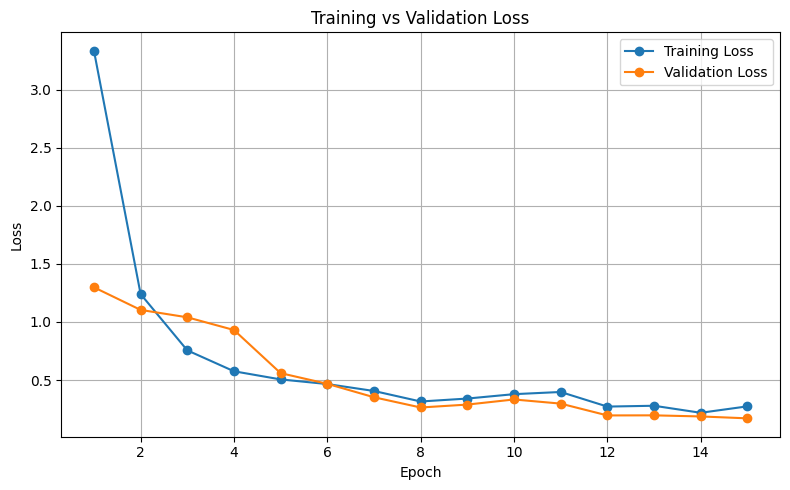

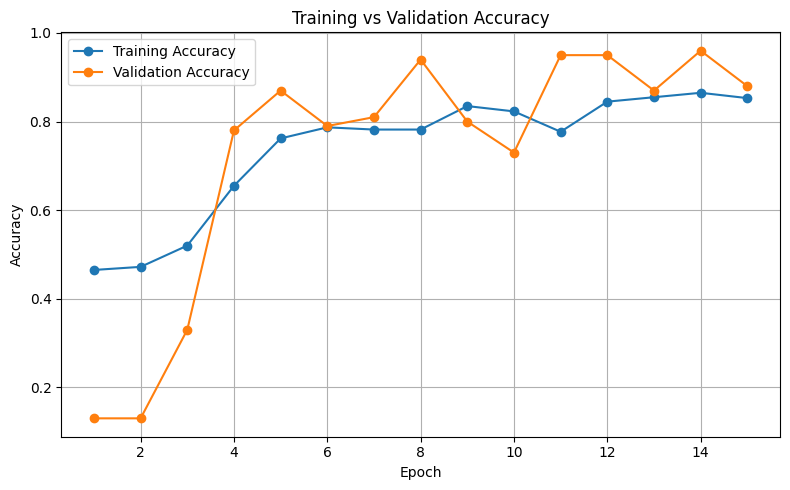

Saved plots as loss_curve.png and accuracy_curve.png


In [1]:
import matplotlib.pyplot as plt

# -------------------------------
# 1. Enter your epoch metrics here
# -------------------------------
train_loss = [3.3363, 1.2402, 0.7557, 0.5756, 0.5055, 0.4654, 0.4058, 0.3153, 0.3406, 0.3784,
              0.3972, 0.2715, 0.2786, 0.2181, 0.2733]

val_loss   = [1.2986, 1.1040, 1.0404, 0.9310, 0.5594, 0.4674, 0.3518, 0.2636, 0.2887, 0.3327,
              0.2971, 0.1953, 0.1960, 0.1865, 0.1702]

train_acc = [0.465, 0.472, 0.520, 0.655, 0.762, 0.787, 0.782, 0.782, 0.835, 0.823,
             0.777, 0.845, 0.855, 0.865, 0.853]

val_acc   = [0.130, 0.130, 0.330, 0.780, 0.870, 0.790, 0.810, 0.940, 0.800, 0.730,
             0.950, 0.950, 0.870, 0.960, 0.880]


epochs = list(range(1, len(train_loss) + 1))

# -------------------------------
# 2. Plot LOSS Curve
# -------------------------------
plt.figure(figsize=(8,5))
plt.plot(epochs, train_loss, marker='o', label='Training Loss')
plt.plot(epochs, val_loss, marker='o', label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("loss_curve.png", dpi=300)
plt.show()

# -------------------------------
# 3. Plot ACCURACY Curve
# -------------------------------
plt.figure(figsize=(8,5))
plt.plot(epochs, train_acc, marker='o', label='Training Accuracy')
plt.plot(epochs, val_acc, marker='o', label='Validation Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("accuracy_curve.png", dpi=300)
plt.show()

print("Saved plots as loss_curve.png and accuracy_curve.png")


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report

# -----------------------------------------
# 1. Your true & predicted labels (exactly as given)
# -----------------------------------------
y_true = [1, 1, 1, 2, 2, 2, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 2, 1, 0, 0,
          1, 2, 1, 2, 1, 1, 2, 1, 1, 2, 1, 0, 0, 1, 2, 1, 1,
          1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1,
          1, 1, 1, 1, 1, 2, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1,
          1, 2, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 2, 1, 1, 0,
          1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 0, 0, 1, 1]

y_pred = [1, 1, 1, 2, 2, 2, 2, 1, 0, 2, 1, 0, 1, 1, 0, 0, 2, 1, 0, 0,
          1, 2, 1, 2, 2, 1, 2, 1, 1, 2, 1, 1, 0, 1, 2, 0, 1,
          2, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1,
          1, 2, 1, 2, 1, 2, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1,
          1, 2, 1, 1, 2, 1, 0, 1, 1, 1, 0, 1, 2, 1, 1, 0,
          2, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 0, 0, 1, 1]

class_names = ["Entry-wise (0)", "Row-wise (1)", "Adaptive (2)"]

# Safety check
print("len(y_true) =", len(y_true))
print("len(y_pred) =", len(y_pred))

# -----------------------------------------
# 2. Confusion matrix
# -----------------------------------------
cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])
cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)
print("\nConfusion Matrix:")
print(cm_df)

# Save confusion matrix plot
plt.figure(figsize=(6, 5))
plt.imshow(cm, interpolation='nearest')
plt.title("Confusion Matrix")
plt.colorbar()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45, ha="right")
plt.yticks(tick_marks, class_names)

# Add counts inside cells
thresh = cm.max() / 2.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                 ha="center", va="center",
                 color="white" if cm[i, j] > thresh else "black")

plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=300)
plt.close()
print("Saved confusion_matrix.png")

# -----------------------------------------
# 3. Classification report (table)
# -----------------------------------------
report_dict = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    output_dict=True
)

report_df = pd.DataFrame(report_dict).T
print("\nClassification Report:")
print(report_df)

# Save as CSV and LaTeX
report_df.to_csv("classification_report.csv", float_format="%.3f")
report_df.to_latex("classification_report.tex", float_format="%.3f")
print("Saved classification_report.csv and classification_report.tex")

# -----------------------------------------
# 4. Short text summary for your report
# -----------------------------------------
overall_acc = report_dict["accuracy"]
macro_avg = report_dict["macro avg"]
weighted_avg = report_dict["weighted avg"]

summary_lines = []
summary_lines.append("=== Precision Strategy Classification Metrics ===\n")
summary_lines.append(f"Overall accuracy: {overall_acc:.3f}\n")
summary_lines.append("Per-class performance:\n")

for cls in class_names:
    m = report_dict[cls]
    summary_lines.append(
        f"  {cls}: precision = {m['precision']:.3f}, "
        f"recall = {m['recall']:.3f}, "
        f"F1-score = {m['f1-score']:.3f}, support = {m['support']:.0f}"
    )

summary_lines.append("\nMacro average: "
                     f"precision = {macro_avg['precision']:.3f}, "
                     f"recall = {macro_avg['recall']:.3f}, "
                     f"F1-score = {macro_avg['f1-score']:.3f}")
summary_lines.append("Weighted average: "
                     f"precision = {weighted_avg['precision']:.3f}, "
                     f"recall = {weighted_avg['recall']:.3f}, "
                     f"F1-score = {weighted_avg['f1-score']:.3f}")

summary_text = "\n".join(summary_lines)

print("\n\nText summary for report:")
print(summary_text)

with open("metrics_summary.txt", "w") as f:
    f.write(summary_text)

print("\nSaved files:")
print("  - confusion_matrix.png")
print("  - classification_report.csv")
print("  - classification_report.tex")
print("  - metrics_summary.txt")


len(y_true) = 100
len(y_pred) = 100

Confusion Matrix:
                Entry-wise (0)  Row-wise (1)  Adaptive (2)
Entry-wise (0)              14             2             0
Row-wise (1)                 2            61             8
Adaptive (2)                 0             0            13
Saved confusion_matrix.png

Classification Report:
                precision    recall  f1-score  support
Entry-wise (0)   0.875000  0.875000  0.875000    16.00
Row-wise (1)     0.968254  0.859155  0.910448    71.00
Adaptive (2)     0.619048  1.000000  0.764706    13.00
accuracy         0.880000  0.880000  0.880000     0.88
macro avg        0.820767  0.911385  0.850051   100.00
weighted avg     0.907937  0.880000  0.885830   100.00
Saved classification_report.csv and classification_report.tex


Text summary for report:
=== Precision Strategy Classification Metrics ===

Overall accuracy: 0.880

Per-class performance:

  Entry-wise (0): precision = 0.875, recall = 0.875, F1-score = 0.875, support = 16
